In [254]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## Loading Dataset

In [255]:
df = pd.read_csv(r'./Data/insurance.csv')

## EDA & Data Cleaning

In [256]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [257]:
df.drop(columns = ['region'], inplace = True)

In [258]:
df.shape

(1338, 6)

In [259]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 62.8+ KB


In [260]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [261]:
df.duplicated().sum()

np.int64(1)

In [262]:
df.drop_duplicates(inplace = True)

In [263]:
df.describe(include = 'object')

,sex,smoker
count,1337,1337
unique,2,2
top,male,no
freq,675,1063


In [264]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
charges     0
dtype: int64

In [265]:
df.sample()

,age,sex,bmi,children,smoker,charges
189,29,female,32.11,2,no,4922.9159


In [266]:
continious_features = ['age', 'bmi', 'charges']
descreate_feature = 'children'
nominal_features = ['sex', 'smoker']

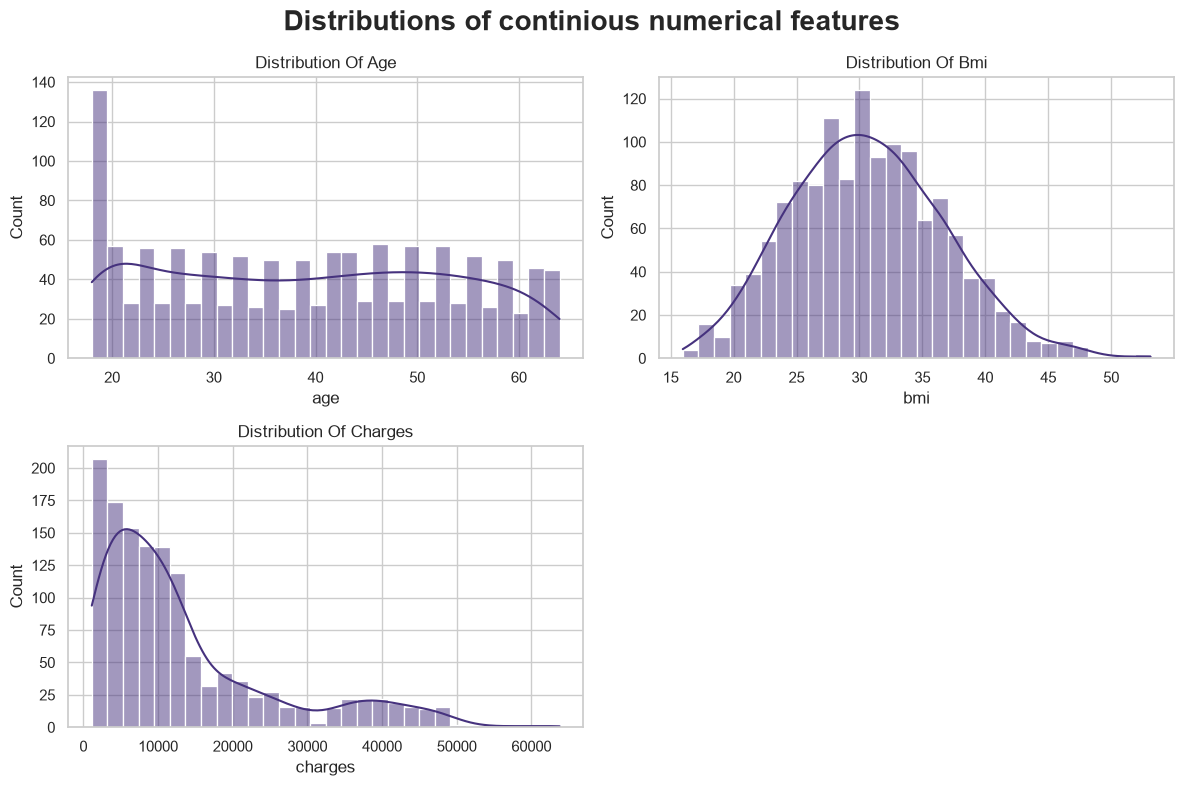

In [267]:
sns.set_theme(style = "whitegrid", palette = "viridis")
fig, axes = plt.subplots(2, 2, figsize = (12, 8))
axes = axes.flatten()

for i, col in enumerate(continious_features):
    sns.histplot(
        df[col],
        ax = axes[i],
        kde = True,
        bins = 30,
    )
    axes[i].set_title(f'distribution of {col}'.title())

fig.suptitle('Distributions of continious numerical features', fontsize = 20, fontweight = 'bold')
axes[3].remove()
plt.tight_layout()
plt.savefig('./Plots and charts/con_numeric_features', dpi = 300)
plt.show()

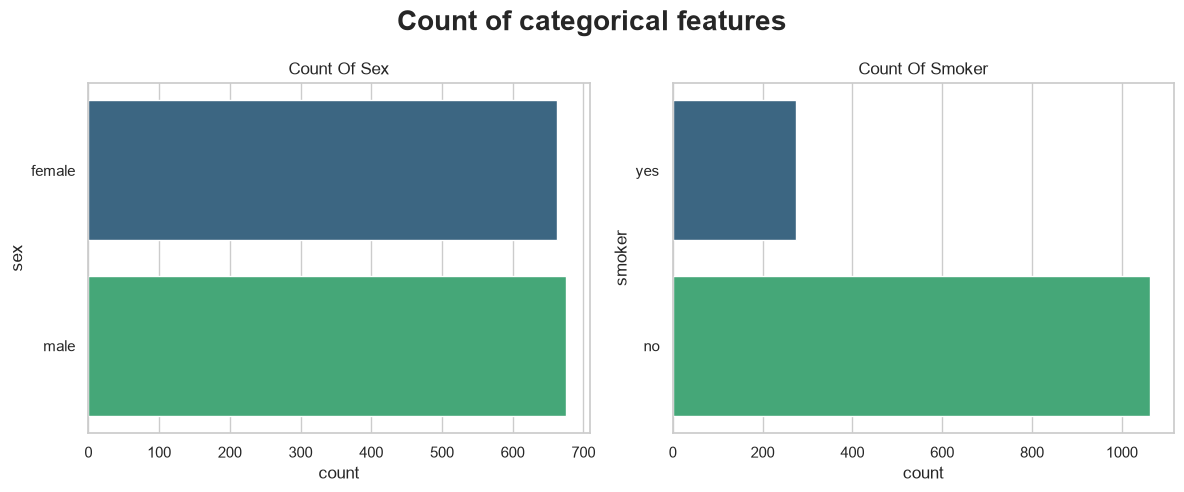

In [268]:
sns.set_theme(style = "whitegrid", palette = "viridis")
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
axes = axes.flatten()

for i, col in enumerate(nominal_features):
    sns.countplot(
        df[col],
        ax = axes[i],
        palette = 'viridis'
    )
    axes[i].set_title(f'Count of {col}'.title())

fig.suptitle('Count of categorical features', fontsize = 20, fontweight = 'bold')
plt.tight_layout()
plt.savefig('./Plots and charts/count_categorical_features', dpi = 300)
plt.show()

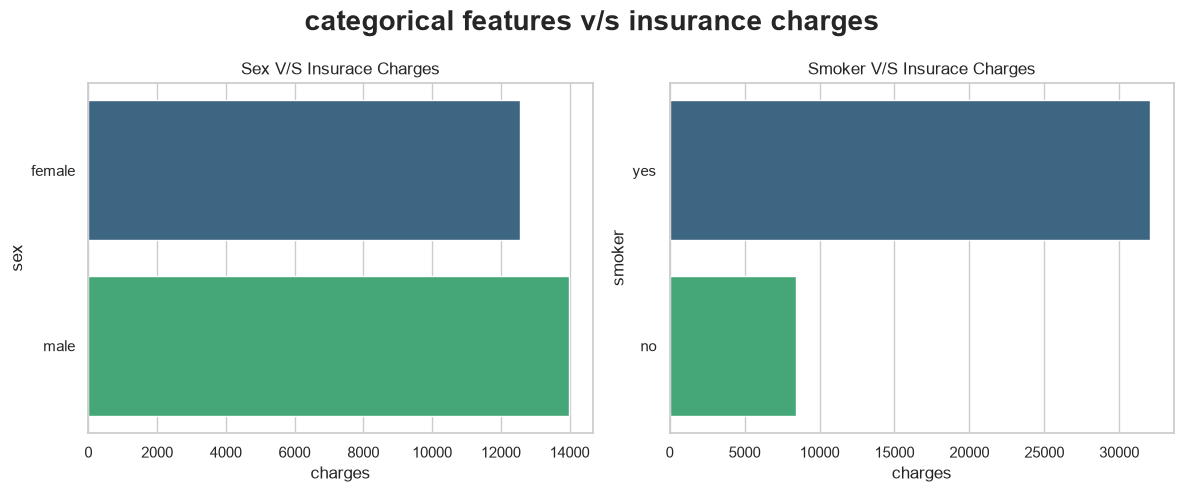

In [269]:
sns.set_theme(style = "whitegrid", palette = "viridis")
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
axes = axes.flatten()

for i, col in enumerate(nominal_features):
    sns.barplot(
        y = df[col],
        x = df['charges'],
        ax = axes[i],
        palette = 'viridis',
        errorbar = None
    )
    axes[i].set_title(f'{col} v/s insurace charges'.title())

fig.suptitle('categorical features v/s insurance charges', fontsize = 20, fontweight = 'bold')
plt.tight_layout()
plt.savefig('./Plots and charts/CE_vs_charges', dpi = 300)
plt.show()

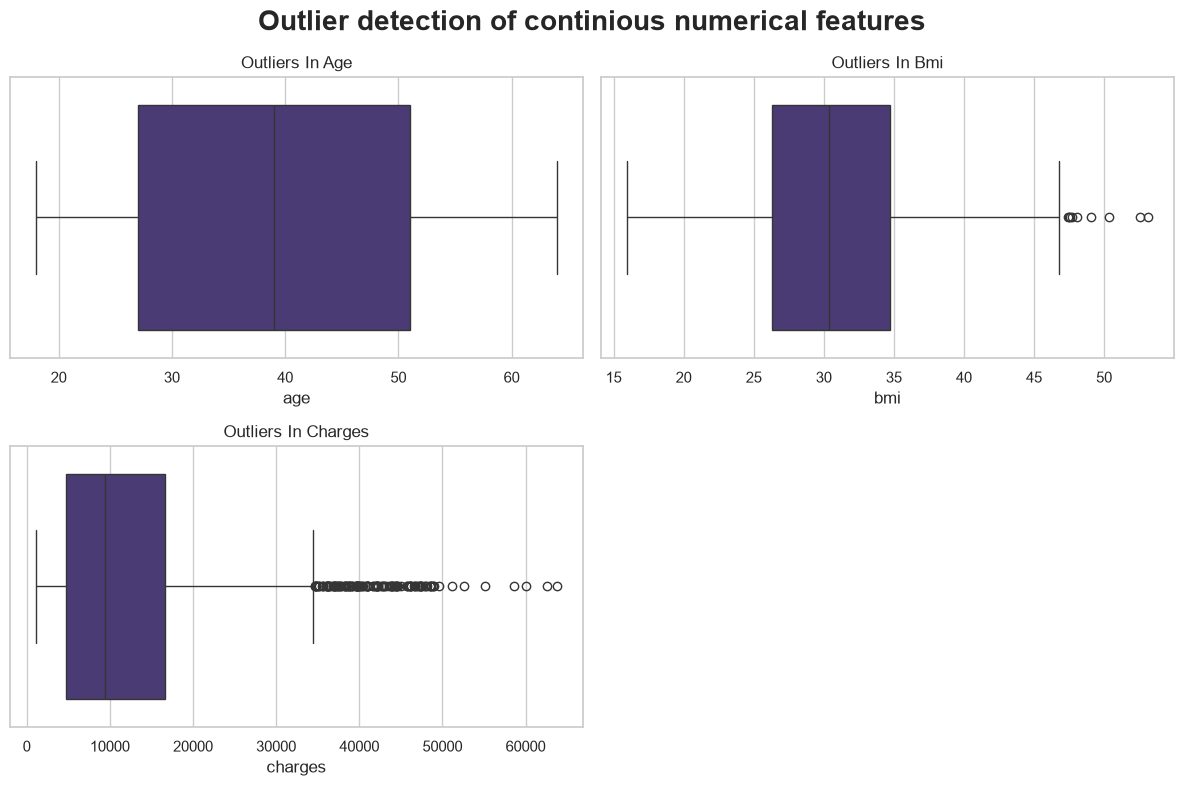

In [270]:
sns.set_theme(style = "whitegrid", palette = "viridis")
fig, axes = plt.subplots(2, 2, figsize = (12, 8))
axes = axes.flatten()

for i, col in enumerate(continious_features):
    sns.boxplot(
        x = df[col],
        ax = axes[i]
    )
    axes[i].set_title(f'Outliers in {col}'.title())

fig.suptitle('Outlier detection of continious numerical features', fontsize = 20, fontweight = 'bold')
axes[3].remove()
plt.tight_layout()
plt.savefig('./Plots and charts/outlier_con_numeric_features', dpi = 300)
plt.show()

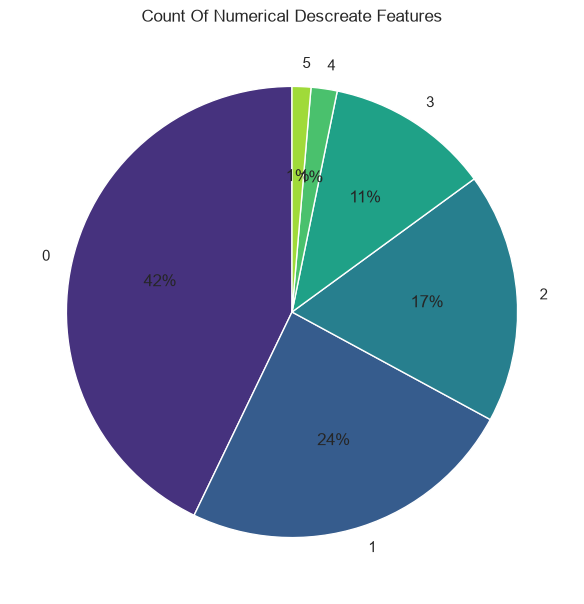

In [271]:
plt.figure(figsize = (6, 8))
plt.pie(
    x = df.children.value_counts().values,
    labels = df.children.value_counts().index,
    autopct = '%i%%',
    startangle = 90
)

plt.title('Count of numerical descreate features'.title())
plt.tight_layout()
plt.savefig('./Plots and charts/disc_numeric_features', dpi = 300)
plt.show()

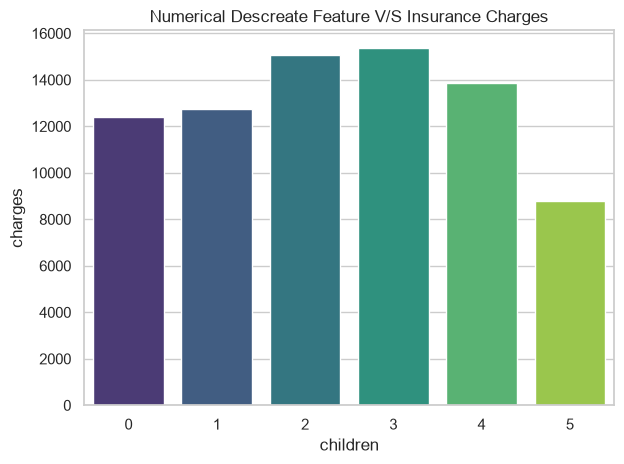

In [272]:
sns.barplot(
    x = df[descreate_feature],
    y = df['charges'],
    errorbar = None,
    palette = 'viridis' 
)
plt.title('numerical descreate feature v/s insurance charges'.title())
plt.tight_layout()
plt.savefig('./Plots and charts/DF_vs_charges', dpi = 300)
plt.show()

## Feature Engineering

In [273]:
df['is_obese'] = np.where(df['bmi'] >= 30, 'yes', 'no')

In [274]:
df['has_children'] = np.where(df['children'] > 0, 'yes', 'no')

In [275]:
df['obese_smoker'] = np.where((df['bmi'] >= 30) & (df['smoker'] == 'yes'), 'yes', 'no')

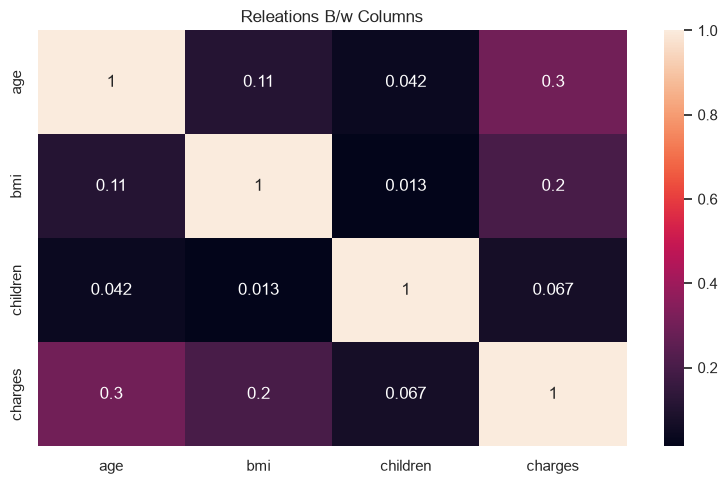

In [276]:
plt.figure(figsize = (8, 5))
sns.heatmap(df.corr(numeric_only = True), annot = True)
plt.title('Releations B/w Columns')
plt.tight_layout()
plt.savefig('./Plots and charts/Heatmap', dpi = 300)
plt.show()

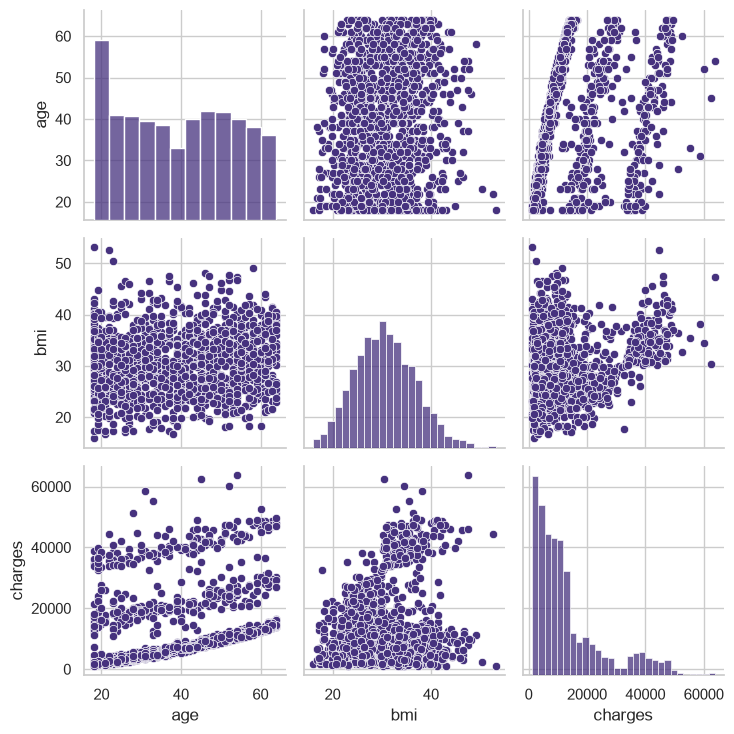

In [277]:
sns.pairplot(df[continious_features])
plt.tight_layout()
plt.savefig('./Plots and charts/scatterplots', dpi = 300)
plt.show()

In [278]:
df.sample(2)

,age,sex,bmi,children,smoker,charges,is_obese,has_children,obese_smoker
416,52,male,34.1,0,no,9140.951,yes,no,no
437,35,male,28.9,3,no,5926.846,no,yes,no


## Piplines

In [279]:
scale_feature = ['age', 'bmi']
OH_enc = ['sex', 'smoker', 'is_obese', 'has_children', 'obese_smoker']

In [280]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder

In [281]:
preprocessor = ColumnTransformer(transformers = [
    ('scaler', StandardScaler(), scale_feature),
    ('OHE', OneHotEncoder(drop = 'first'), OH_enc)
], remainder = 'passthrough')

## Train Test Split

In [282]:
X = df.drop(columns = ['charges'])
y = df['charges']

In [283]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, shuffle = True)

## Models

In [284]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

### LinearRegression

In [285]:
lr_model = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [286]:
lr_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['age','sex','bmi',...,'is_obese','has_children','obese_smoker']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('OHE', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis con

In [287]:
print('Train')
print(lr_model.score(X_train, y_train))
print('Test')
print(lr_model.score(X_test, y_test))

Train
0.8473688512735413
Test
0.9049092395876349


### Ridge

In [288]:
ridge_model = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha = 0.01))
])

In [289]:
ridge_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['age','sex','bmi',...,'is_obese','has_children','obese_smoker']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('OHE', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis con

In [290]:
print('Train')
print(ridge_model.score(X_train, y_train))
print('Test')
print(ridge_model.score(X_test, y_test))

Train
0.8473688478356536
Test
0.9049053690410996


### Lasso

In [291]:
lasso_model = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha = 0.01))
])

In [292]:
lasso_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['age','sex','bmi',...,'is_obese','has_children','obese_smoker']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('OHE', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis con

In [293]:
print('Train')
print(lasso_model.score(X_train, y_train))
print('Test')
print(lasso_model.score(X_test, y_test))

Train
0.8473688512347968
Test
0.904908670634744


### DecisionTreeRegressor

In [294]:
dt_model = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(max_depth = 5))
])

In [295]:
dt_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['age','sex','bmi',...,'is_obese','has_children','obese_smoker']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('OHE', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis con

In [296]:
print('Train')
print(dt_model.score(X_train, y_train))
print('Test')
print(dt_model.score(X_test, y_test))

Train
0.8629966020705101
Test
0.8902958886519342


### RandomForestRegressor

In [297]:
rf_model = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators = 300,
        max_depth = 6,
        random_state = 42,
        max_leaf_nodes = 60
    ))
])

In [298]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['age','sex','bmi',...,'is_obese','has_children','obese_smoker']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('OHE', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis con

In [299]:
print('Train')
print(rf_model.score(X_train, y_train))
print('Test')
print(rf_model.score(X_test, y_test))

Train
0.8817576832056572
Test
0.9009674534349263


### XGBRegressor

In [300]:
xgb_model = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators = 400,
        max_depth = 3,
        learning_rate = 0.03
    ))
])

In [301]:
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['age','sex','bmi',...,'is_obese','has_children','obese_smoker']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('OHE', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis con

In [302]:
print('Train')
print(xgb_model.score(X_train, y_train))
print('Test')
print(xgb_model.score(X_test, y_test))

Train
0.8854161051628262
Test
0.9010869904415654


## Model Evaluation DF

In [303]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

models = {
    'Linear Regression': lr_model,
    'Ridge' : ridge_model,
    'Lasso' : lasso_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

evaluation_results = []

for model_name, model in models.items():
    for dataset_name, features, target in [
        ('Train', X_train, y_train),
        ('Test', X_test, y_test)
    ]:
        predictions = model.predict(features)

        evaluation_results.append({
            'Model': model_name,
            'Dataset': dataset_name,
            'R2 Score': round(r2_score(target, predictions) * 100, 2),
            'MAE': round(mean_absolute_error(target, predictions), 2),
            'RMSE': round(np.sqrt(mean_squared_error(target, predictions)), 2)
        })

evaluation_df = pd.DataFrame(evaluation_results)
evaluation_df.sort_values(['Dataset', 'R2 Score'], ascending=[True, False])

,Model,Dataset,R2 Score,MAE,RMSE
1,Linear Regression,Test,90.49,2354.16,4180.13
3,Ridge,Test,90.49,2354.25,4180.22
5,Lasso,Test,90.49,2354.18,4180.14
11,XGBoost,Test,90.11,2460.11,4263.32
9,Random Forest,Test,90.10,2418.27,4265.89
7,Decision Tree,Test,89.03,2673.87,4489.85
10,XGBoost,Train,88.54,2138.37,3960.84
8,Random Forest,Train,88.18,2169.19,4023.57
6,Decision Tree,Train,86.30,2438.17,4331.02
0,Linear Regression,Train,84.74,2530.03,4571.37


Winner Model : Linear Regression 🎉

In [304]:
df.sample(random_state = 42)

,age,sex,bmi,children,smoker,charges,is_obese,has_children,obese_smoker
900,49,male,22.515,0,no,8688.85885,no,no,no


In [305]:
age = 49
sex = 'male'
bmi = 22.515
children = 0
smoker = 'no'
region = 'northeast'
is_obese = 'no'
has_children = 'no'
obese_smoker = 'no'

actual_charges = 8688.85885

clumns = ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'is_obese', 'has_children', 'obese_smoker']
inp_data = pd.DataFrame([[age, sex, bmi, children, smoker, region, is_obese, has_children, obese_smoker]], columns = clumns)

predicted_charges = lr_model.predict(inp_data)[0]

In [306]:
print(f'Actual Charges: {actual_charges:.2f}')
print(f'Predicted Charges: {predicted_charges:.2f}\n')
print(f'Gap B/W Them {predicted_charges  - actual_charges}')

Actual Charges: 8688.86
Predicted Charges: 9786.03

Gap B/W Them 1097.170985999417


## Model Save

In [307]:
# ---------------------------------------------------------
# Export trained model + SHAP artifacts for deployment
# ---------------------------------------------------------
import os
import joblib

os.makedirs('./Trained_Model', exist_ok=True)

# Save the same model used in the evaluation below.
joblib.dump(
    lr_model,
    './Trained_Model/insurance_charges_model.pkl'
)

# IMPORTANT:
# SHAP must compare a user's row against representative training data.
# Do NOT use the current user's row as the SHAP background.
shap_background_df = X_train.sample(
    n=min(200, len(X_train)),
    random_state=42
)

shap_preprocessor = lr_model.named_steps['preprocessor']
shap_background = shap_preprocessor.transform(shap_background_df)

# Save dense matrix so the FastAPI service can load it directly.
if hasattr(shap_background, 'toarray'):
    shap_background = shap_background.toarray()

shap_feature_names = (
    shap_preprocessor
    .get_feature_names_out()
    .tolist()
)

joblib.dump(
    shap_background,
    './Trained_Model/shap_background.pkl'
)

joblib.dump(
    shap_feature_names,
    './Trained_Model/shap_feature_names.pkl'
)

print('Model saved successfully:')
print('  ./Trained_Model/insurance_charges_model.pkl')
print('SHAP artifacts saved successfully:')
print('  ./Trained_Model/shap_background.pkl')
print('  ./Trained_Model/shap_feature_names.pkl')
print(f'  Background rows: {shap_background.shape[0]}')
print(f'  Transformed features: {shap_background.shape[1]}')
print(f'  Feature names: {shap_feature_names}')


Model saved successfully:
  ./Trained_Model/insurance_charges_model.pkl
SHAP artifacts saved successfully:
  ./Trained_Model/shap_background.pkl
  ./Trained_Model/shap_feature_names.pkl
  Background rows: 200
  Transformed features: 8
  Feature names: ['scaler__age', 'scaler__bmi', 'OHE__sex_male', 'OHE__smoker_yes', 'OHE__is_obese_yes', 'OHE__has_children_yes', 'OHE__obese_smoker_yes', 'remainder__children']
